# Практичне завдання 1: Лінійна регресія, оптимізація та статистичний аналіз

Датасет: House Prices (Ames Housing, версія з Kaggle), файл `data/train.csv`.
Цільова змінна: `SalePrice`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(42)

SUPERSCRIPT = str.maketrans('-0123456789', '⁻⁰¹²³⁴⁵⁶⁷⁸⁹')


def sci(x, digits=3):
    # Записує число як a · 10ⁿ, наприклад 591700000 -> 5.917 · 10⁸
    if x == 0 or not np.isfinite(x):
        return str(x)
    power = int(np.floor(np.log10(abs(x))))
    return f'{x / 10**power:.{digits}f} · 10{str(power).translate(SUPERSCRIPT)}'

## Етап 1. EDA, відбір ознак та попередня обробка

### 1.1 Первинний аналіз даних

In [2]:
df = pd.read_csv('data/train.csv')
print('Розмір:', df.shape)
df.head()

Розмір: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Типи ознак
print(df.dtypes.value_counts())

str        43
int64      35
float64     3
Name: count, dtype: int64


In [4]:
# Пропущені значення (тільки колонки, де вони є)
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [5]:
# Статистичні характеристики цільової змінної та кількох числових ознак
df[['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt', 'LotArea']].describe()

,SalePrice,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,LotArea
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,180921.195890,6.099315,1515.463699,1.767123,1057.429452,1971.267808,10516.828082
std,79442.502883,1.382997,525.480383,0.747315,438.705324,30.202904,9981.264932
min,34900.000000,1.000000,334.000000,0.000000,0.000000,1872.000000,1300.000000
25%,129975.000000,5.000000,1129.500000,1.000000,795.750000,1954.000000,7553.500000
50%,163000.000000,6.000000,1464.000000,2.000000,991.500000,1973.000000,9478.500000
75%,214000.000000,7.000000,1776.750000,2.000000,1298.250000,2000.000000,11601.500000
max,755000.000000,10.000000,5642.000000,4.000000,6110.000000,2010.000000,215245.000000


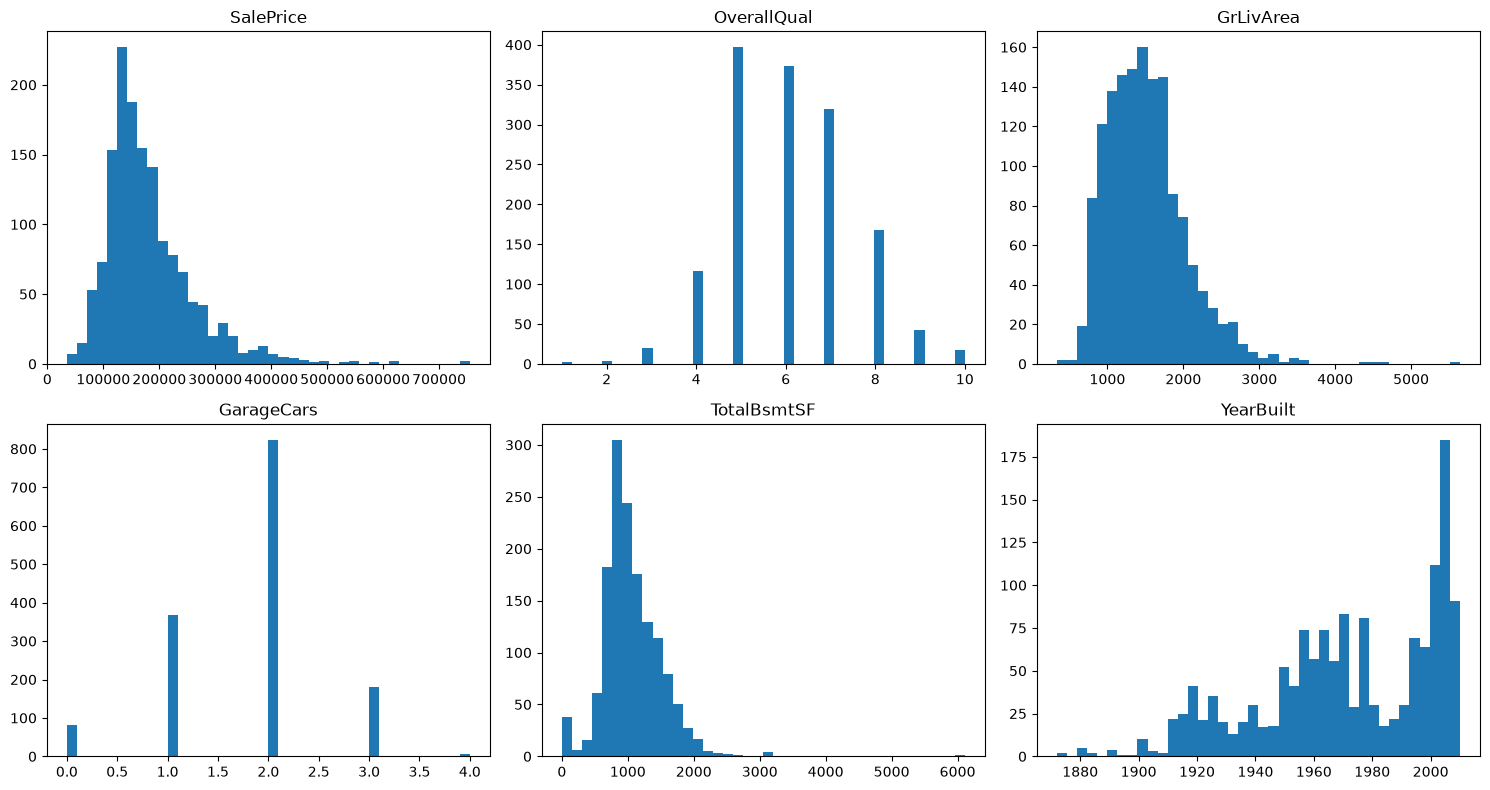

In [6]:
# Розподіли основних змінних
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), cols):
    ax.hist(df[col], bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Висновки EDA:**
- 1460 будинків, 81 колонка: 43 текстові (категоріальні) та 38 числових.
- Пропуски є переважно в ознаках, яких у більшості будинків просто немає (`PoolQC`, `MiscFeature`, `Alley`, `Fence`). Ці колонки ми не використовуємо.
- `SalePrice` має правосторонню асиметрію: більшість будинків коштує 100-250 тис., але є дорогі викиди до 755 тис.
- Ознаки мають дуже різні масштаби (`GarageCars` від 0 до 4, `LotArea` до 215 тис.), тому потрібне масштабування.

### 1.2 Розбиття вибірки

Розбиваємо дані **першим кроком**, щоб відбір ознак, кодування і масштабування робилися тільки на Train.
Пропорції: 70% Train, 15% Validation, 15% Test.

**Питання: чому розбивати треба до масштабування, кодування та інших операцій, які навчаються на даних?**

Data Leakage (витік даних) - це ситуація, коли під час навчання модель прямо або непрямо отримує інформацію з Validation/Test.
Наприклад, якщо порахувати середнє і стандартне відхилення для стандартизації на всьому датасеті, то в параметри
препроцесингу потрапить інформація з тестових даних. Тоді оцінка на Test буде завищеною і не покаже, як модель працює на
справді нових даних. Тому всі "навчувані" кроки (scaler, encoder, відбір ознак) робимо `fit` тільки на Train, а до
Validation і Test лише застосовуємо `transform`.

In [7]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
print('Train:', train_df.shape, ' Validation:', val_df.shape, ' Test:', test_df.shape)

Train: (1022, 81)  Validation: (219, 81)  Test: (219, 81)


### 1.3 Відбір ознак

Метод: кореляція Пірсона числових ознак із `SalePrice`, порахована **тільки на Train**.
Беремо ознаки з |кореляцією| > 0.5, а потім перевіряємо кореляції між самими ознаками.

In [8]:
numeric_cols = train_df.select_dtypes('number').columns.drop(['Id', 'SalePrice'])
corr_with_target = train_df[numeric_cols].corrwith(train_df['SalePrice']).abs().sort_values(ascending=False)
corr_with_target.head(15)

OverallQual     0.784720
GrLivArea       0.689238
GarageCars      0.642689
GarageArea      0.621937
TotalBsmtSF     0.590017
1stFlrSF        0.583132
FullBath        0.549164
TotRmsAbvGrd    0.519634
YearBuilt       0.512206
YearRemodAdd    0.512190
GarageYrBlt     0.474363
Fireplaces      0.461329
MasVnrArea      0.454514
BsmtFinSF1      0.360559
LotFrontage     0.340251
dtype: float64

Кандидати: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


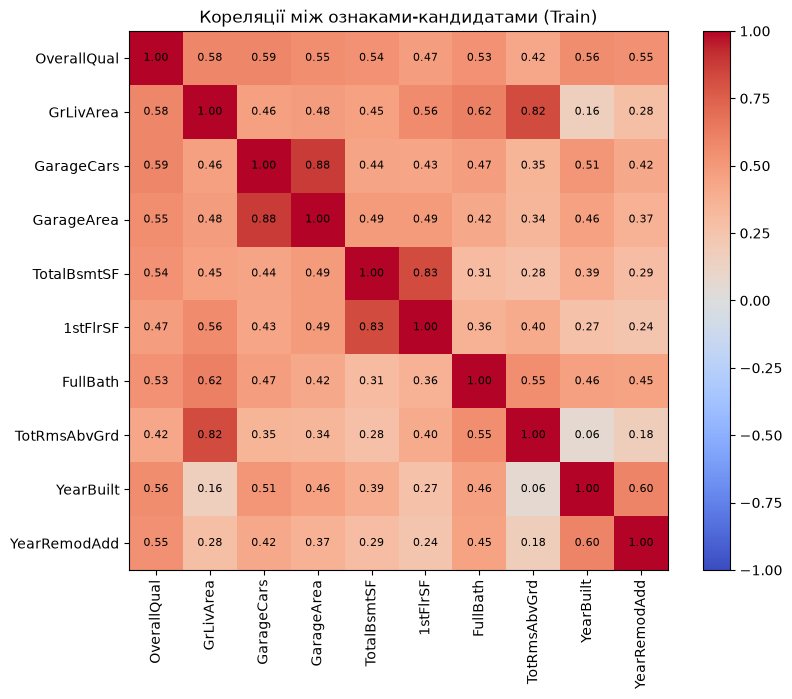

In [9]:
candidates = corr_with_target[corr_with_target > 0.5].index.tolist()
print('Кандидати:', candidates)

corr_matrix = train_df[candidates].corr()
plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(candidates)), candidates, rotation=90)
plt.yticks(range(len(candidates)), candidates)
for i in range(len(candidates)):
    for j in range(len(candidates)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('Кореляції між ознаками-кандидатами (Train)')
plt.show()

In [10]:
# Пари ознак із сильною кореляцією між собою (> 0.8) - ознака мультиколінеарності
for i in range(len(candidates)):
    for j in range(i + 1, len(candidates)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            print(candidates[i], '-', candidates[j], round(corr_matrix.iloc[i, j], 2))

GrLivArea - TotRmsAbvGrd 0.82
GarageCars - GarageArea 0.88
TotalBsmtSF - 1stFlrSF 0.83


**Обрані ознаки та чому саме вони:**

Сильно корельовані пари дублюють одна одну (наприклад, кількість машин у гаражі і площа гаража описують одне й те саме).
З кожної пари залишаємо ознаку, яка сильніше корелює з `SalePrice`:
- `GarageCars` замість `GarageArea`
- `TotalBsmtSF` замість `1stFlrSF`
- `GrLivArea` замість `TotRmsAbvGrd`

Числові ознаки: `OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, `FullBath`, `YearBuilt`, `YearRemodAdd`.

Категоріальні ознаки:
- `KitchenQual` - якість кухні (логічно впливає на ціну і має природний порядок);
- `Neighborhood` - район (розташування сильно впливає на ціну будинку).

Пропусків у цих ознаках немає, тому заповнювати нічого не потрібно.

In [11]:
num_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt', 'YearRemodAdd']
target = 'SalePrice'

print(train_df[num_features + ['KitchenQual', 'Neighborhood']].isna().sum().sum(), 'пропусків')

0 пропусків


### 1.4 Кодування категорій

- `KitchenQual` має природний порядок (Po < Fa < TA < Gd < Ex), тому використовуємо **Ordinal Encoding** (1..5).
- `Neighborhood` не має порядку (район A не "більший" за район B), тому використовуємо **One-Hot Encoding**.
  Ordinal тут задав би штучний порядок, а Target Encoding складніший і без обережності сам по собі дає Data Leakage через цільову змінну.

**Питання: як обробляти категорії, яких не було в Train?**

Для One-Hot ставимо `handle_unknown='ignore'`: нова категорія кодується вектором з усіх нулів,
тобто модель використовує для такого будинку тільки bias та інші ознаки, без поправки на район.
Для `KitchenQual` у словнику є всі можливі значення зі специфікації датасету, тому нових значень не буде.

In [12]:
quality_map = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

def get_numeric(data):
    X = data[num_features].copy()
    X['KitchenQual'] = data['KitchenQual'].map(quality_map)
    return X

# encoder навчається тільки на Train
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(train_df[['Neighborhood']])
print('Кількість One-Hot колонок:', len(encoder.categories_[0]))

Кількість One-Hot колонок: 25


### 1.5 Масштабування

Стандартизація `z = (x - mean) / std` для числових ознак. `mean` і `std` рахуються тільки на Train.
One-Hot колонки (0/1) не масштабуємо.

In [13]:
scaler = StandardScaler()
scaler.fit(get_numeric(train_df))

def prepare(data, scale=True):
    X_num = get_numeric(data).values
    if scale:
        X_num = scaler.transform(get_numeric(data))
    X_cat = encoder.transform(data[['Neighborhood']])
    return np.hstack([X_num, X_cat])

X_train, X_val, X_test = prepare(train_df), prepare(val_df), prepare(test_df)
y_train = train_df[target].values.astype(float)
y_val = val_df[target].values.astype(float)
y_test = test_df[target].values.astype(float)

feature_names = num_features + ['KitchenQual'] + list(encoder.get_feature_names_out())
print('X_train:', X_train.shape, ' X_val:', X_val.shape, ' X_test:', X_test.shape)

X_train: (1022, 33)  X_val: (219, 33)  X_test: (219, 33)


## Етап 2. Лінійна регресія на numpy

Модель: $\hat{y} = Xw + b$

Функція втрат (MSE): $J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$

Градієнти (у векторній формі):

$\frac{\partial J}{\partial w} = \frac{1}{m} X^T (\hat{y} - y), \qquad \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$

Оновлення параметрів: $w := w - \alpha \frac{\partial J}{\partial w}, \quad b := b - \alpha \frac{\partial J}{\partial b}$

Усі обчислення векторизовані, без циклів `for`.

In [14]:
def predict(X, w, b):
    return X @ w + b


def compute_cost(X, y, w, b):
    m = len(y)
    error = predict(X, w, b) - y
    return (error @ error) / (2 * m)


def compute_gradients(X, y, w, b):
    m = len(y)
    error = predict(X, w, b) - y
    dw = X.T @ error / m
    db = error.sum() / m
    return dw, db


def update_parameters(w, b, dw, db, lr):
    return w - lr * dw, b - lr * db

## Етап 3. Градієнтний спуск: три варіанти

Одна функція покриває всі три варіанти, різниця тільки в розмірі batch:
- **Batch GD**: `batch_size = m` (весь Train за один крок);
- **SGD**: `batch_size = 1` (оновлення після кожного прикладу);
- **Mini-batch GD**: `batch_size = 32`.

На початку кожної епохи дані перемішуються. Після кожної епохи зберігаємо значення Cost на всьому Train.

Критерій зупинки: максимальна кількість епох `epochs`. Додатково можна передати `tol`: навчання зупиняється, коли відносна зміна Cost між епохами стає меншою за `tol`.
`tol` використовуємо тільки для Batch GD. У SGD і Mini-batch Cost шумний, дві сусідні епохи можуть випадково дати майже однаковий Cost, тому для них просто фіксуємо кількість епох.

In [15]:
def gradient_descent(X, y, lr, epochs, batch_size, tol=None, seed=42):
    rng = np.random.default_rng(seed)
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    history = [compute_cost(X, y, w, b)]

    for epoch in range(epochs):
        indices = rng.permutation(m)
        # цикл тільки по batch-ах, градієнт всередині рахується векторно
        for start in range(0, m, batch_size):
            batch = indices[start:start + batch_size]
            dw, db = compute_gradients(X[batch], y[batch], w, b)
            w, b = update_parameters(w, b, dw, db, lr)

        history.append(compute_cost(X, y, w, b))
        if tol is not None and abs(history[-2] - history[-1]) / history[-2] < tol:
            print(f'Зупинка на епосі {epoch + 1}')
            break

    return w, b, history

Learning Rate підібрано вручну: пробували значення 0.001, 0.01, 0.1, 0.3, 0.5 і брали найбільше, при якому Cost стабільно спадає.
- Batch GD: lr = 0.3 (при 0.5 вже розходиться). Робить лише 1 оновлення за епоху, тому йому потрібно ~1000 епох.
- SGD: lr = 0.001. Робить ~1000 оновлень за епоху і кожне шумне, тому потрібен малий крок.
- Mini-batch GD: lr = 0.01.

In [16]:
m_train = X_train.shape[0]

w_batch, b_batch, hist_batch = gradient_descent(X_train, y_train, lr=0.3, epochs=2000, batch_size=m_train, tol=1e-6)
w_sgd, b_sgd, hist_sgd = gradient_descent(X_train, y_train, lr=0.001, epochs=300, batch_size=1)
w_mini, b_mini, hist_mini = gradient_descent(X_train, y_train, lr=0.01, epochs=300, batch_size=32)

Зупинка на епосі 1136


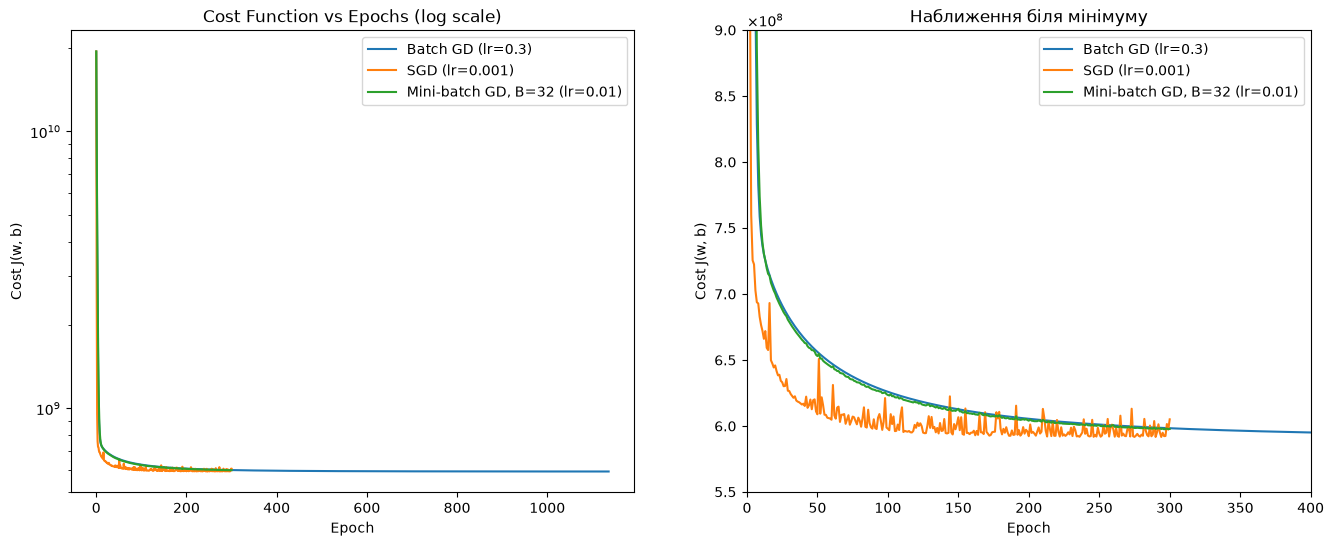

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax in axes:
    ax.plot(hist_batch, label='Batch GD (lr=0.3)')
    ax.plot(hist_sgd, label='SGD (lr=0.001)')
    ax.plot(hist_mini, label='Mini-batch GD, B=32 (lr=0.01)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cost J(w, b)')
    ax.legend()

axes[0].set_yscale('log')
axes[0].set_title('Cost Function vs Epochs (log scale)')

# наближення, щоб побачити коливання біля мінімуму
axes[1].set_xlim(0, 400)
axes[1].set_ylim(5.5e8, 9e8)
axes[1].ticklabel_format(axis='y', useMathText=True)  # множник осі як ×10⁸
axes[1].set_title('Наближення біля мінімуму')
plt.show()

In [18]:
# Коливання Cost на останніх 50 епохах
for name, h in [('Batch GD', hist_batch), ('SGD', hist_sgd), ('Mini-batch GD', hist_mini)]:
    last = np.array(h[-50:])
    print(f'{name:15s} final cost = {sci(last[-1])}   std за останні 50 епох = {sci(last.std())}')

Batch GD        final cost = 5.917 · 10⁸   std за останні 50 епох = 9.358 · 10³
SGD             final cost = 6.054 · 10⁸   std за останні 50 епох = 5.001 · 10⁶
Mini-batch GD   final cost = 5.981 · 10⁸   std за останні 50 епох = 7.979 · 10⁵


**Аналіз графіків:**

- **Найстабільніше збігається Batch GD**: градієнт рахується по всьому Train, тобто це точний напрямок спуску.
  Крива Cost гладка і монотонно спадає, коливання за останні 50 епох майже нульові, і він дійшов до найменшого Cost.
  Мінус: одне оновлення за епоху, тому для повної збіжності знадобилось ~1100 епох.
- **Найбільші коливання має SGD**: кожен крок робиться по одному будинку, градієнт дуже шумний, тому Cost "стрибає"
  навколо мінімуму і не зупиняється точно в ньому (найбільше std за останні епохи). Зате на старті Cost спадає найшвидше,
  бо за одну епоху SGD робить ~1000 оновлень.
- **Розмір batch**: чим менший batch, тим більше оновлень за епоху (швидше спадає Cost на початку), але тим більший шум.
  Чим більший batch, тим точніший градієнт і стабільніше навчання, але менше оновлень за епоху.
  Mini-batch (B=32) - компроміс: спадає швидко і коливається приблизно в 6 разів менше, ніж SGD.
  Також batch-обчислення добре векторизуються, тому одна епоха Mini-batch набагато швидша за епоху SGD.
- **Learning Rate**: замалий lr - Cost спадає дуже повільно (Mini-batch з lr=0.001 за 300 епох не дійшов до мінімуму, див. Етап 6);
  завеликий lr - кроки "перестрибують" мінімум, Cost коливається (Mini-batch з lr=0.1) або росте до нескінченності
  (Batch GD з lr=0.5 розходиться). Для SGD допустимий lr найменший, бо кожен окремий крок шумний.

## Етап 4. Оцінка якості: R²

$R^2 = 1 - \frac{\sum (y^{(i)} - \hat{y}^{(i)})^2}{\sum (y^{(i)} - \bar{y})^2}$

In [19]:
def r2_score(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot


results = {}
for name, w, b in [('Batch GD', w_batch, b_batch), ('SGD', w_sgd, b_sgd), ('Mini-batch GD', w_mini, b_mini)]:
    results[name] = {
        'R2 Train': r2_score(y_train, predict(X_train, w, b)),
        'R2 Validation': r2_score(y_val, predict(X_val, w, b)),
        'R2 Test': r2_score(y_test, predict(X_test, w, b)),
    }
pd.DataFrame(results).T.round(4)

,R2 Train,R2 Validation,R2 Test
Batch GD,0.8034,0.8800,0.8086
SGD,0.7988,0.8714,0.7911
Mini-batch GD,0.8012,0.8803,0.8054


**Статистичний зміст R².** R² показує, яку частку дисперсії цільової змінної пояснює модель.
Знаменник - це помилка "найпростішої моделі", яка завжди передбачає середнє $\bar{y}$; чисельник - помилка нашої моделі.
R² = 0.8 означає, що модель пояснює близько 80% варіації цін, а 20% залишаються непоясненими.

**Чи може R² бути від'ємним?** Так. Якщо модель передбачає гірше, ніж просто середнє значення,
то $\sum (y - \hat{y})^2 > \sum (y - \bar{y})^2$ і R² < 0. Таке буває на Validation/Test при сильному перенавчанні,
при недонавченій моделі (наприклад, GD зупинили зарано або він розійшовся) або якщо модель зовсім не підходить до даних.

**Train vs Test.** Для Batch GD R² на Train = 0.80, на Test = 0.81, тобто вони майже однакові.
Це означає, що модель **не перенавчилась**: на нових даних вона працює так само, як на навчальних.
Водночас ~20% дисперсії не пояснено, тобто лінійна модель трохи **недонавчена** (underfitting): залежність ціни від ознак не зовсім лінійна (див. Етап 5).
R² на Validation (0.88) вищий через випадковість розбиття: у маленькій вибірці (219 будинків) могло потрапити менше складних викидів.

**Порівняння трьох варіантів GD.** Якість майже однакова (різниця R² менше 0.02), бо всі три методи
мінімізують ту саму опуклу функцію і приходять в околицю одного мінімуму.
Найкращий результат у Batch GD (Test R² = 0.809), бо він дійшов точно до мінімуму.
Mini-batch дуже близько (0.805). SGD трохи гірший (0.791), бо через шум зупиняється у випадковій точці поруч із мінімумом.

## Етап 5. Перевірка статистичних припущень

Аналізуємо залишки $\epsilon = y - \hat{y}$ моделі Batch GD на Train.

In [20]:
fitted = predict(X_train, w_batch, b_batch)
residuals = y_train - fitted
std_residuals = residuals / residuals.std()

### 5.1 Лінійність: Residuals vs Fitted

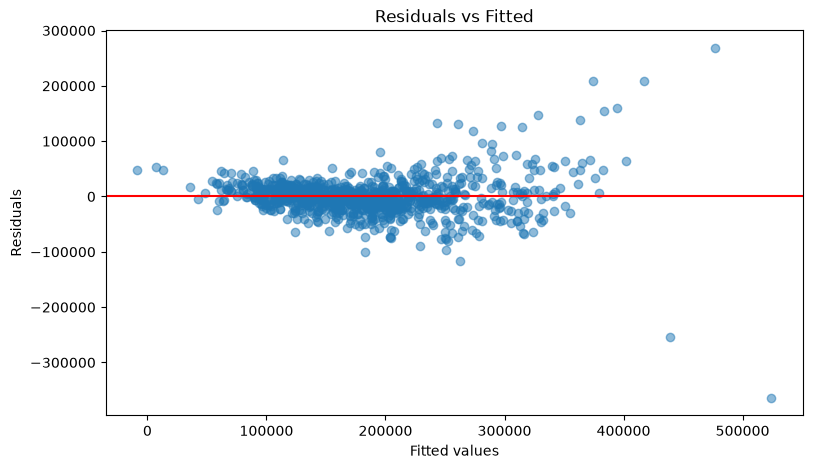

In [21]:
plt.figure(figsize=(9, 5))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

**Висновок.** Припущення лінійності **частково порушується**, тому що залишки не зовсім випадково розкидані навколо 0:
для найдешевших будинків (fitted < 100 тис.) залишки переважно додатні, а для дорогих (fitted > 300 тис.) розкид сильно зростає
і є великі додатні залишки. Модель недооцінює дешеві й дорогі будинки, тобто ціна росте швидше, ніж лінійно.
Також видно два сильні викиди з великою від'ємною помилкою (дуже великі будинки з низькою ціною продажу).
Це означає, що лінійна модель описує основну масу даних добре, але для крайніх значень ціни дає систематичну помилку.

### 5.2 Нормальність залишків: гістограма, Q-Q plot, тест Шапіро-Уїлка

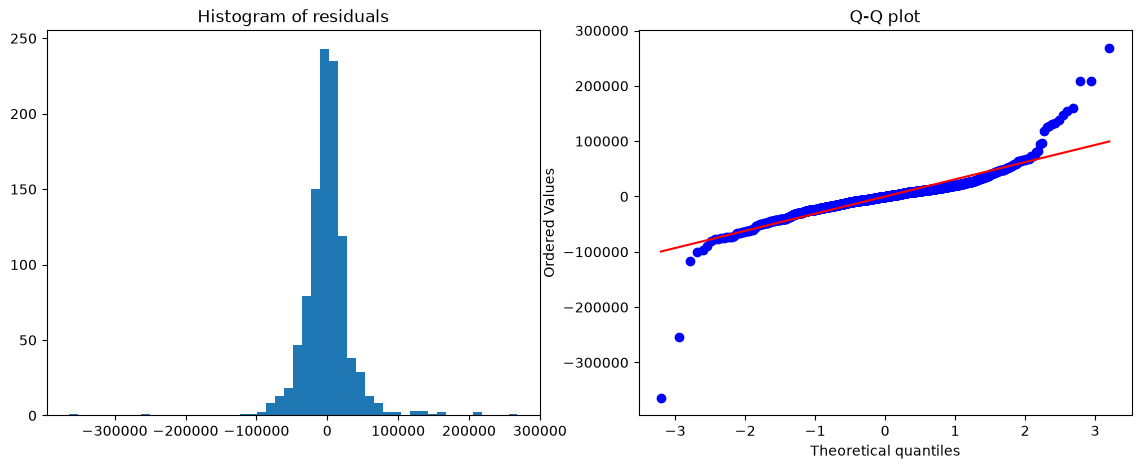

Shapiro-Wilk: W = 0.8160, p-value = 1.32 · 10⁻³²


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(residuals, bins=50)
axes[0].set_title('Histogram of residuals')
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot')
plt.show()

stat, p_value = stats.shapiro(residuals)
print(f'Shapiro-Wilk: W = {stat:.4f}, p-value = {sci(p_value, 2)}')

**Висновок.** Припущення нормальності **порушується**, тому що тест Шапіро-Уїлка дає p-value набагато менше 0.05
(гіпотезу про нормальний розподіл відкидаємо), а на Q-Q plot точки на краях сильно відходять від прямої ("важкі хвости").
Гістограма в центрі схожа на нормальну, але є дуже великі помилки в обидва боки.
Це означає, що передбачення моделі використовувати можна, але класичні довірчі інтервали і p-values для коефіцієнтів
будуть неточними, а викиди сильно впливають на MSE і на ваги.

### 5.3 Гомоскедастичність: Scale-Location

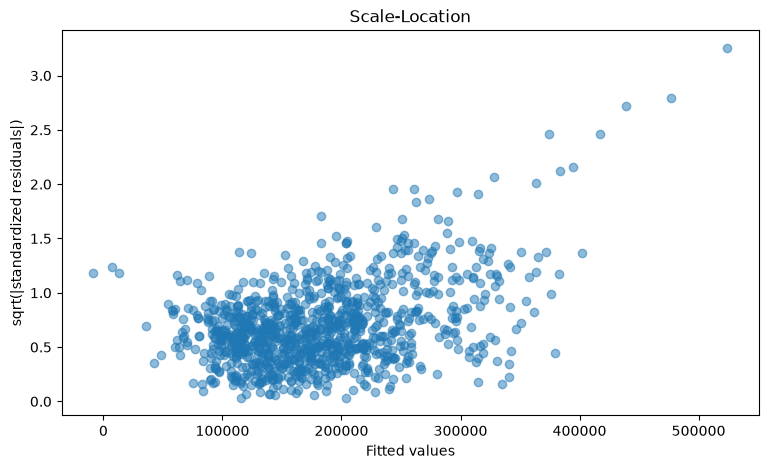

In [23]:
plt.figure(figsize=(9, 5))
plt.scatter(fitted, np.sqrt(np.abs(std_residuals)), alpha=0.5)
plt.xlabel('Fitted values')
plt.ylabel('sqrt(|standardized residuals|)')
plt.title('Scale-Location')
plt.show()

**Висновок.** Припущення гомоскедастичності **порушується**, тому що на графіку Scale-Location точки піднімаються вгору
зі збільшенням fitted values: чим дорожчий будинок, тим більша помилка. Дисперсія помилок **не** однакова (гетероскедастичність,
форма "лійки" видна й на Residuals vs Fitted).
Це означає, що для дешевих будинків модель точніша, ніж для дорогих, і одна метрика якості "в середньому" приховує цю різницю.
Зазвичай це виправляють логарифмуванням цільової змінної (log SalePrice).

### 5.4 Мультиколінеарність: VIF

$VIF_j = \frac{1}{1 - R_j^2}$, де $R_j^2$ - це R² регресії ознаки j на всі інші ознаки.
Цей самий результат дають діагональні елементи оберненої кореляційної матриці, тому рахуємо так.
Правило: VIF < 5 - нормально, 5-10 - помірна, > 10 - сильна мультиколінеарність.

VIF рахуємо для числових ознак. One-Hot колонки району разом завжди дають у сумі 1, тому між собою
вони лінійно залежні за побудовою, і VIF для них не інформативний.

In [24]:
X_num_train = get_numeric(train_df)
vif = np.diag(np.linalg.inv(X_num_train.corr().values))
pd.Series(vif, index=X_num_train.columns, name='VIF').round(2).sort_values(ascending=False)

OverallQual     2.93
GrLivArea       2.54
KitchenQual     2.38
YearBuilt       2.36
FullBath        2.16
YearRemodAdd    2.07
GarageCars      1.84
TotalBsmtSF     1.59
Name: VIF, dtype: float64

In [25]:
# Порівняння ваг числових ознак для трьох методів (стабільність коефіцієнтів)
n_num = len(num_features) + 1
pd.DataFrame({
    'Batch GD': w_batch[:n_num],
    'SGD': w_sgd[:n_num],
    'Mini-batch GD': w_mini[:n_num],
}, index=feature_names[:n_num]).round(0)

,Batch GD,SGD,Mini-batch GD
OverallQual,18088.0,17065.0,18696.0
GrLivArea,23372.0,21700.0,23427.0
GarageCars,9250.0,8725.0,9721.0
TotalBsmtSF,8108.0,6508.0,7986.0
FullBath,-553.0,-992.0,-775.0
YearBuilt,4490.0,4007.0,6325.0
YearRemodAdd,3256.0,2774.0,3196.0
KitchenQual,8966.0,8159.0,9079.0


**Висновок.** Припущення відсутності мультиколінеарності **виконується**, тому що всі VIF < 3 (менше порогу 5).
Це результат відбору ознак на Етапі 1: ми вже прибрали пари з кореляцією > 0.8 (`GarageArea`, `1stFlrSF`, `TotRmsAbvGrd`).

**Чи вплинула мультиколінеарність на коефіцієнти?** Суттєво ні. Три методи GD дали ваги з однаковими знаками і близькими значеннями,
тобто коефіцієнти стабільні. Найбільший вплив на ціну мають `GrLivArea` і `OverallQual` (ознаки стандартизовані, тому ваги можна порівнювати між собою).
Помірні кореляції все ж трохи видно:
- `FullBath` має малу від'ємну вагу, хоча сама по собі корелює з ціною позитивно. Причина: вона корелює з `GrLivArea` (0.62),
  і ефект "більше ванних = більший будинок" уже врахований через площу. Тому інтерпретувати знак цієї ваги окремо не варто.
- Вага `YearBuilt` помітно відрізняється між методами (4000-6300), бо ознака корелює з `YearRemodAdd` (0.60) та `OverallQual` (0.56),
  і модель може частково "перерозподіляти" ефект між ними.

## Етап 6. Експеримент А: вплив масштабування

Запускаємо Mini-batch GD (B=32) на тих самих ознаках, але **без стандартизації** числових ознак,
і порівнюємо зі стандартизованими даними. Learning Rate підбираємо для кожного випадку окремо.

In [26]:
X_train_raw = prepare(train_df, scale=False)

# Підбір lr без масштабування
for lr in [1e-6, 1e-7, 1e-8]:
    with np.errstate(all='ignore'):
        _, _, h = gradient_descent(X_train_raw, y_train, lr=lr, epochs=300, batch_size=32)
    print(f'lr = {sci(lr, 0)}: final cost = {sci(h[-1])}')

lr = 1 · 10⁻⁶: final cost = nan
lr = 1 · 10⁻⁷: final cost = 1.289 · 10⁹


lr = 1 · 10⁻⁸: final cost = 1.294 · 10⁹


In [27]:
# Підбір lr зі стандартизацією
for lr in [0.1, 0.01, 0.001]:
    _, _, h = gradient_descent(X_train, y_train, lr=lr, epochs=300, batch_size=32)
    print(f'lr = {lr}: final cost = {sci(h[-1])}')

lr = 0.1: final cost = 7.322 · 10⁸


lr = 0.01: final cost = 5.981 · 10⁸
lr = 0.001: final cost = 6.794 · 10⁸


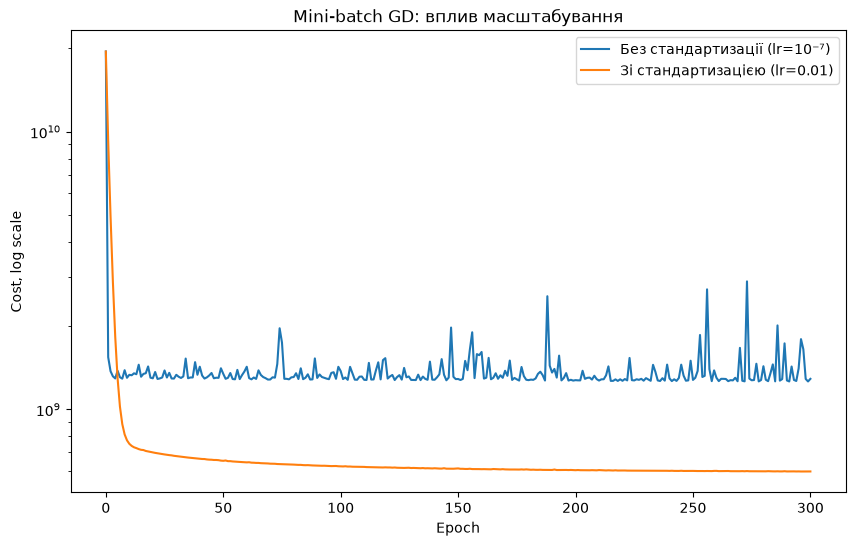

R2 Train без стандартизації: 0.5717
R2 Train зі стандартизацією: 0.8012


In [28]:
w_raw, b_raw, hist_raw = gradient_descent(X_train_raw, y_train, lr=1e-7, epochs=300, batch_size=32)

plt.figure(figsize=(10, 6))
plt.plot(hist_raw, label='Без стандартизації (lr=10⁻⁷)')
plt.plot(hist_mini, label='Зі стандартизацією (lr=0.01)')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Cost, log scale')
plt.title('Mini-batch GD: вплив масштабування')
plt.legend()
plt.show()

print('R2 Train без стандартизації:', round(r2_score(y_train, predict(X_train_raw, w_raw, b_raw)), 4))
print('R2 Train зі стандартизацією:', round(r2_score(y_train, predict(X_train, w_mini, b_mini)), 4))

**Результати:**
- **Без стандартизації** при lr = 10⁻⁶ алгоритм розходиться (Cost = nan). Максимальний робочий lr = 10⁻⁷, але навіть тоді
  за 300 епох Cost застряг на рівні ~1.3 · 10⁹ зі стрибками, а R² на Train лише ~0.57.
- **Зі стандартизацією** можна брати lr = 0.01 (у 100 000 разів більший), Cost плавно спадає до ~6.0 · 10⁸, R² на Train ~0.80.
  (lr = 0.1 вже нестабільний, lr = 0.001 занадто повільний.)

**Геометричне пояснення.** Лінії рівня функції втрат J(w) - це еліпси. Якщо ознаки мають однаковий масштаб,
еліпси близькі до кіл, і антиградієнт вказує майже прямо на мінімум. Без масштабування ознаки мають зовсім різні діапазони
(`YearBuilt` ~2000, `TotalBsmtSF` до 6000, а One-Hot колонки 0/1), тому еліпси стають дуже витягнутими:
вздовж ваг "великих" ознак функція дуже крута, а вздовж ваг "малих" ознак і bias дуже полога.
Learning Rate обмежений найкрутішим напрямком (інакше в ньому кроки перестрибують мінімум і алгоритм розходиться),
тому в пологих напрямках кроки стають мізерними. У результаті GD йде зигзагом поперек "ущелини" і дуже повільно
рухається вздовж неї до мінімуму. Стандартизація вирівнює масштаби, і GD сходиться швидко з великим lr.